In [1]:
pip install pandas


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install anaconda

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd, numpy as np
from pathlib import Path
import os

In [4]:
df = pd.read_csv("loan_approval_dataset.csv")

In [5]:
print(type(df))


<class 'pandas.DataFrame'>


In [6]:
df.columns.to_list()
df.columns = df.columns.str.strip()
print(df.columns)


Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='str')


In [7]:
df.shape,
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   loan_id                   4269 non-null   int64
 1   no_of_dependents          4269 non-null   int64
 2   education                 4269 non-null   str  
 3   self_employed             4269 non-null   str  
 4   income_annum              4269 non-null   int64
 5   loan_amount               4269 non-null   int64
 6   loan_term                 4269 non-null   int64
 7   cibil_score               4269 non-null   int64
 8   residential_assets_value  4269 non-null   int64
 9   commercial_assets_value   4269 non-null   int64
 10  luxury_assets_value       4269 non-null   int64
 11  bank_asset_value          4269 non-null   int64
 12  loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 433.7 KB


EDA

In [9]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing>0]

Series([], dtype: int64)

In [10]:
duplicates= df.drop_duplicates(inplace=True)
print(duplicates)

None


In [11]:
import sys
print(sys.executable)


c:\Users\ADARSH\OneDrive\Desktop\ADITI\ml_project\advenv\Scripts\python.exe


In [12]:
!pip install matplotlib seaborn



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

Using target column: loan_status


loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

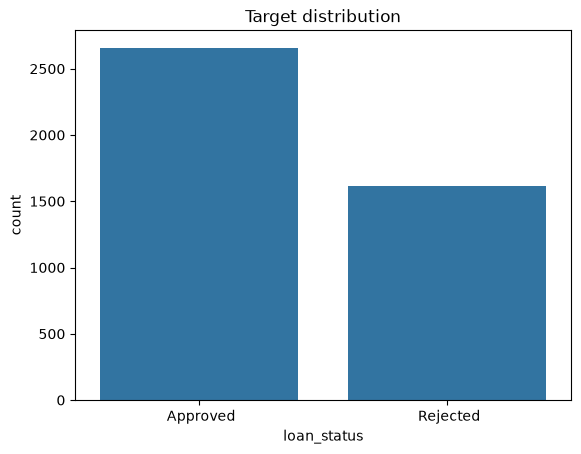

In [14]:
target_col = 'loan_status'
print('Using target column:', target_col)
display(df[target_col].value_counts(dropna=False))
sns.countplot(x=target_col, data=df)
plt.title('Target distribution')
plt.show()

In [15]:
target_col = "loan_status"
id_cols = ["loan_id"] 
df = df.drop(columns=['loan_id'])
df_cop = df.dropna(subset=[target_col]).copy()
print(df_cop)

      no_of_dependents      education self_employed  income_annum  \
0                    2       Graduate            No       9600000   
1                    0   Not Graduate           Yes       4100000   
2                    3       Graduate            No       9100000   
3                    3       Graduate            No       8200000   
4                    5   Not Graduate           Yes       9800000   
...                ...            ...           ...           ...   
4264                 5       Graduate           Yes       1000000   
4265                 0   Not Graduate           Yes       3300000   
4266                 2   Not Graduate            No       6500000   
4267                 1   Not Graduate            No       4100000   
4268                 1       Graduate            No       9200000   

      loan_amount  loan_term  cibil_score  residential_assets_value  \
0        29900000         12          778                   2400000   
1        12200000          8 

In [16]:
X = df_cop.drop(columns=[target_col])
y = df_cop[target_col]



In [17]:
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)

Categorical columns: ['education', 'self_employed']
Numerical columns: ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


C:\Users\ADARSH\AppData\Local\Temp\ipykernel_8604\444349429.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()


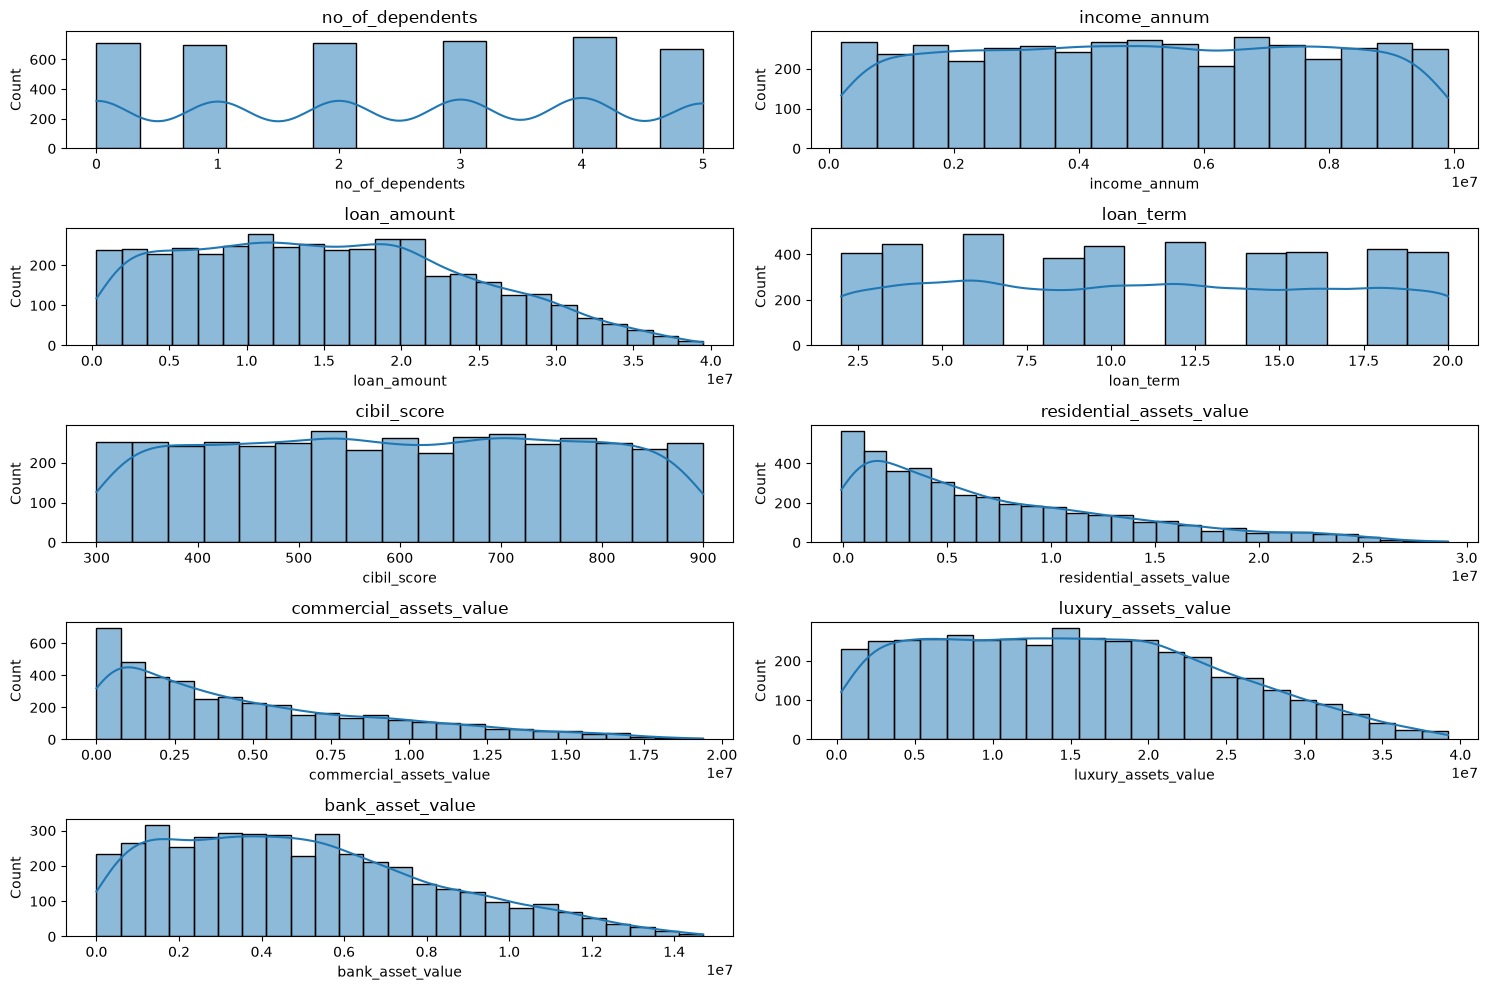

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

n = len(num_cols)

plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot((n+1)//2, 2, i)   # 2 columns
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

<Axes: >

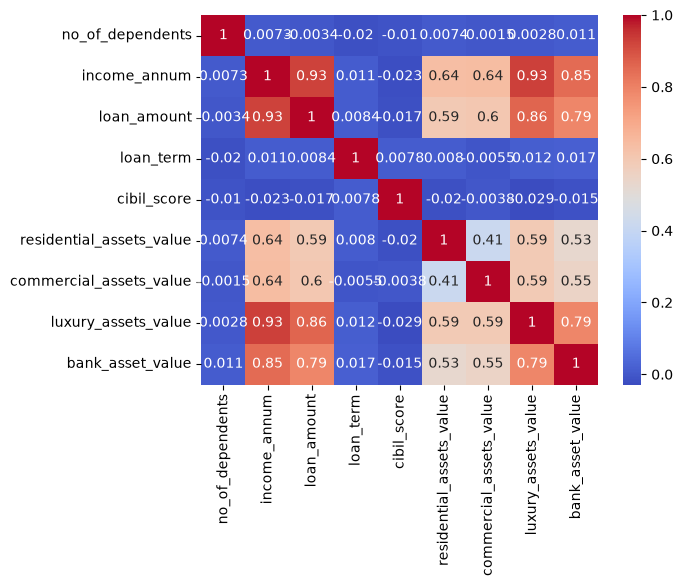

In [19]:
corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

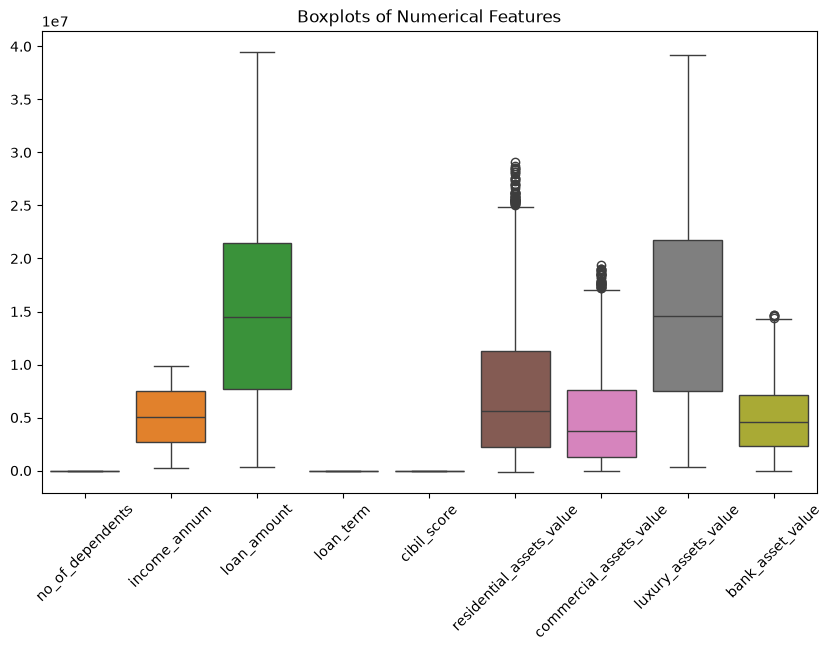

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Features")
plt.show()

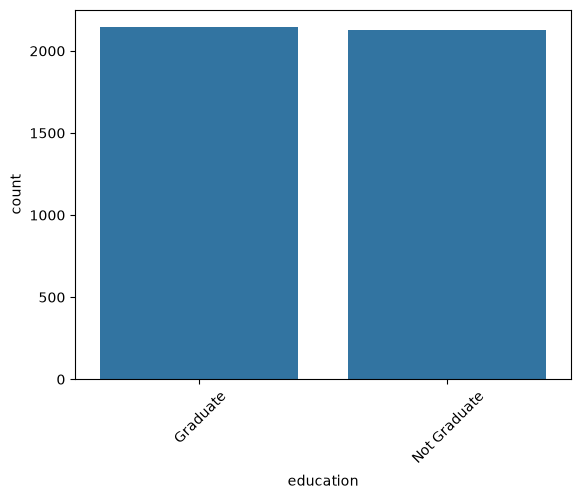

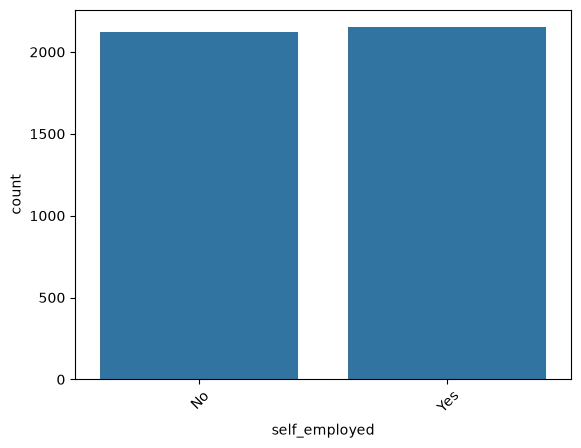

In [21]:
for col in cat_cols:
    sns.countplot(x=col, data=df_cop)
    plt.xticks(rotation=45)
    plt.show()

In [22]:
!pip install scikit-learn



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [24]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [25]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
], remainder='drop')



In [26]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [28]:
unique_vals = sorted(y.unique())

unique_vals

[' Approved', ' Rejected']

In [29]:
y = df_cop[target_col].astype(str).str.strip().str.lower()
unique_vals = sorted(y.unique())
unique_vals

['approved', 'rejected']

In [30]:
y = (y == 'approved').astype(int)
y.head()


0    1
1    0
2    0
3    0
4    0
Name: loan_status, dtype: int64

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train/test sizes:", X_train.shape, X_test.shape)

Train/test sizes: (3415, 11) (854, 11)


In [32]:
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('rf', RandomForestClassifier(random_state=2, oob_score=True))])

In [33]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'rf__n_estimators': [100, 200, 300, 400],
    'rf__max_depth': [None, 4, 8, 10],
    'rf__max_features': ['sqrt', None]
}

In [34]:
grid = GridSearchCV(rf_pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...om_state=2))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'rf__max_depth': [None, 4, ...], 'rf__max_features': ['sqrt', None], 'rf__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, d

In [35]:

print("Best params (RF):", grid.best_params_)

Best params (RF): {'rf__max_depth': 10, 'rf__max_features': None, 'rf__n_estimators': 400}


In [36]:
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('rf', RandomForestClassifier(n_estimators=400, max_depth=10,
                                                            max_features=None,random_state=2, 
                                                            oob_score=True))])


rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
print('Random Forest:')
print(classification_report(y_test, y_pred_rf))
print('RF OOB score (if available):', getattr(rf_pipeline.named_steps['rf'],'oob_score_', None))

Random Forest:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       323
           1       0.98      1.00      0.99       531

    accuracy                           0.99       854
   macro avg       0.99      0.98      0.98       854
weighted avg       0.99      0.99      0.99       854

RF OOB score (if available): 0.9818448023426062


STAGE 2


In [37]:
df['loan_status'] = df['loan_status'].astype(str).str.strip().str.lower()
df['loan_status'].unique()

<StringArray>
['approved', 'rejected']
Length: 2, dtype: str

In [38]:
#approved_df = df[df["loan_status"] == "approved"].copy()
app =  df ["loan_status"] == "approved"

approved_df = df[app].copy()
approved_df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,approved
6,5,Graduate,No,8700000,33000000,4,678,22500000,14800000,29200000,4300000,approved
8,0,Graduate,Yes,800000,2200000,20,782,1300000,800000,2800000,600000,approved
10,4,Graduate,Yes,2900000,11200000,2,547,8100000,4700000,9500000,3100000,approved
13,2,Graduate,Yes,9100000,31500000,14,679,10800000,16600000,20900000,5000000,approved
...,...,...,...,...,...,...,...,...,...,...,...,...
4261,3,Graduate,Yes,3000000,7500000,6,881,1400000,4500000,6100000,2300000,approved
4263,3,Graduate,No,5000000,12700000,14,865,4700000,8100000,19500000,6300000,approved
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,approved
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,approved


In [39]:

reg_df = approved_df.dropna(subset=["loan_amount"]).copy()


In [40]:
reg_target = "loan_amount"
X_reg = reg_df.drop(columns=[reg_target])
y_reg = reg_df[reg_target]
X_reg

,no_of_dependents,education,self_employed,income_annum,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,12,778,2400000,17600000,22700000,8000000,approved
6,5,Graduate,No,8700000,4,678,22500000,14800000,29200000,4300000,approved
8,0,Graduate,Yes,800000,20,782,1300000,800000,2800000,600000,approved
10,4,Graduate,Yes,2900000,2,547,8100000,4700000,9500000,3100000,approved
13,2,Graduate,Yes,9100000,14,679,10800000,16600000,20900000,5000000,approved
...,...,...,...,...,...,...,...,...,...,...,...
4261,3,Graduate,Yes,3000000,6,881,1400000,4500000,6100000,2300000,approved
4263,3,Graduate,No,5000000,14,865,4700000,8100000,19500000,6300000,approved
4265,0,Not Graduate,Yes,3300000,20,559,4200000,2900000,11000000,1900000,approved
4267,1,Not Graduate,No,4100000,8,780,8200000,700000,14100000,5800000,approved


In [41]:
cat_cols_reg = X_reg.select_dtypes(include=['object','category']).columns.tolist()
num_cols_reg = X_reg.select_dtypes(include=[np.number]).columns.to_list()
print("Regression Numerical:", num_cols_reg)
print("Regression Categorical:", cat_cols_reg)


Regression Numerical: ['no_of_dependents', 'income_annum', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
Regression Categorical: ['education', 'self_employed', 'loan_status']


C:\Users\ADARSH\AppData\Local\Temp\ipykernel_8604\2270271032.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_reg = X_reg.select_dtypes(include=['object','category']).columns.tolist()


In [42]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

In [43]:
reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols_reg),
        ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols_reg)
    ],
remainder='drop')

In [44]:
from sklearn.ensemble import RandomForestRegressor
reg_pipe = Pipeline(steps=[
    ('preprocessor', reg_preprocessor),
    ('model', RandomForestRegressor(random_state=42, oob_score=True))
])


param_grid_reg = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5, 10]

}
grid_reg = GridSearchCV(
    reg_pipe,
    param_grid_reg,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

In [45]:
grid_reg.fit(Xr_train, yr_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 5, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verb

In [46]:
print("Best Regression Params:", grid_reg.best_params_)
best_reg = grid_reg.best_estimator_

Best Regression Params: {'model__max_depth': 5, 'model__min_samples_split': 10, 'model__n_estimators': 300}


In [47]:
reg_pipe = Pipeline(steps=[
    ('preprocessor', reg_preprocessor),
    ('model', RandomForestRegressor(max_depth=5, min_samples_split=10,n_estimators=300, random_state=42, oob_score=True))
])

In [48]:
reg_pipe.fit(Xr_train, yr_train)
yr_pred = reg_pipe.predict(Xr_test)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print("Regression metrics on approved applicants:")
print("RMSE:", mean_squared_error(yr_test, yr_pred))
print("MAE:", mean_absolute_error(yr_test, yr_pred))
print("R2:", r2_score(yr_test, yr_pred))

Regression metrics on approved applicants:
RMSE: 10794004746004.68
MAE: 2451526.9067810844
R2: 0.8744177380038414


save artifacts


In [49]:
import joblib

In [50]:
joblib.dump(rf_pipeline, "./stage_1_rf_classifier_pipeline.pkl")
joblib.dump(reg_pipe, "./stage_2_rf_regression_pipeline.pkl")

['./stage_2_rf_regression_pipeline.pkl']

In [51]:
clf = joblib.load('./stage_1_rf_classifier_pipeline.pkl')
reg = joblib.load('./stage_2_rf_regression_pipeline.pkl')

In [52]:
def two_stage_predict(applicant_df):
    out = {}

    # Stage 1
    approve = clf.predict(applicant_df)[0]
    print(approve)
    out['loan_status'] = int(approve)

    if approve == 1:
        # ADD predicted loan_status column to input
        applicant_df_reg = applicant_df.copy()
        applicant_df_reg['loan_status'] = 'approved'

        # Stage 2 prediction
        pred = reg.predict(applicant_df_reg)[0]
        out['regression_prediction'] = float(pred)
    else:
        print("Not approved")

    return out


In [53]:
X_test.iloc[[0]]

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
2856,3,Not Graduate,Yes,8300000,31400000,6,674,1000000,1600000,17200000,6100000


In [54]:
example_row = X_test.iloc[[0]]
example_row.info()

<class 'pandas.DataFrame'>
Index: 1 entries, 2856 to 2856
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   no_of_dependents          1 non-null      int64
 1   education                 1 non-null      str  
 2   self_employed             1 non-null      str  
 3   income_annum              1 non-null      int64
 4   loan_amount               1 non-null      int64
 5   loan_term                 1 non-null      int64
 6   cibil_score               1 non-null      int64
 7   residential_assets_value  1 non-null      int64
 8   commercial_assets_value   1 non-null      int64
 9   luxury_assets_value       1 non-null      int64
 10  bank_asset_value          1 non-null      int64
dtypes: int64(9), str(2)
memory usage: 96.0 bytes


In [55]:
print(reg.feature_names_in_)

['no_of_dependents' 'education' 'self_employed' 'income_annum' 'loan_term'
 'cibil_score' 'residential_assets_value' 'commercial_assets_value'
 'luxury_assets_value' 'bank_asset_value' 'loan_status']


In [56]:
print(clf.feature_names_in_)

['no_of_dependents' 'education' 'self_employed' 'income_annum'
 'loan_amount' 'loan_term' 'cibil_score' 'residential_assets_value'
 'commercial_assets_value' 'luxury_assets_value' 'bank_asset_value']


In [57]:
user_input = {
    "no_of_dependents": int(input("No. of Dependents: ")),
    "education": input("Education (Graduate/Not Graduate): "),
    "self_employed": input("Self Employed (Yes/No): "),
    "income_annum": float(input("Annual Income: ")),
    "loan_amount": float(input("Loan Amount Requested: ")),
    "loan_term": int(input("Loan Term (in years): ")),
    "cibil_score": int(input("CIBIL Score: ")),
    "residential_assets_value": float(input("Residential Assets Value: ")),
    "commercial_assets_value": float(input("Commercial Assets Value: ")),
    "luxury_assets_value": float(input("Luxury Assets Value: ")),
    "bank_asset_value": float(input("Bank Asset Value: "))
}

applicant_df = pd.DataFrame([user_input])

result = two_stage_predict(applicant_df)

print("Final Output:")
print(result)



0
Not approved
Final Output:
{'loan_status': 0}


In [58]:
try:
    print("FEATURE IMPORTANCES:")
    for pipeline, model_key in [(clf, "rf"), (reg, "model")]:
        
        # 1. Extract the actual model step
        model_step = pipeline.named_steps[model_key]
        
        # 2. Get feature names from the PREVIOUS step (or the pipeline input if no resizing happened)
        # If your pipeline has a preprocessor step (e.g., named 'preprocessor'):
        if 'preprocessor' in pipeline.named_steps:
            feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
        else:
            # Fallback to the pipeline's overall input names if it didn't change column count
            feature_names = pipeline.feature_names_in_
            
        # 3. Extract the weights
        importances = model_step.feature_importances_
        
        # 4. Zip and print
        for col, score in zip(feature_names, importances):
            print(f"{col:30s} : {score:.4f}")
            
        print("===" * 10)
        
except AttributeError as e:
    print(f"Extraction failed. Specific error: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


FEATURE IMPORTANCES:
num__no_of_dependents          : 0.0028
num__income_annum              : 0.0255
num__loan_amount               : 0.0353
num__loan_term                 : 0.0869
num__cibil_score               : 0.8256
num__residential_assets_value  : 0.0053
num__commercial_assets_value   : 0.0061
num__luxury_assets_value       : 0.0085
num__bank_asset_value          : 0.0025
cat__education_ Graduate       : 0.0003
cat__education_ Not Graduate   : 0.0003
cat__self_employed_ No         : 0.0004
cat__self_employed_ Yes        : 0.0004
num__no_of_dependents          : 0.0007
num__income_annum              : 0.9792
num__loan_term                 : 0.0027
num__cibil_score               : 0.0050
num__residential_assets_value  : 0.0026
num__commercial_assets_value   : 0.0040
num__luxury_assets_value       : 0.0031
num__bank_asset_value          : 0.0026
cat__education_ Graduate       : 0.0000
cat__education_ Not Graduate   : 0.0000
cat__self_employed_ No         : 0.0001
cat__self_employed_

Stage 1 (Classification): Predicts if an applicant will be approved or rejected.


Stage 2 (Regression): If they are approved, it predicts the optimal loan amount they should receive based on their assets and income.